In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [2]:
words = open("names.txt","r").read().splitlines()
print(len(words))
print(max(len(w)) for w in words)

32033
<generator object <genexpr> at 0x000001327F8D6890>


In [3]:
chars = sorted(set(list("".join(words))))
stoi = {s : i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s,i in stoi.items()}
vocab_size = len(stoi)

In [4]:
import random
random.seed(42)
random.shuffle(words)

In [5]:
block_size = 8

def build_dataset(words):

  X, Y = [],[]


  for w in words:

    context = [0] * block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X, Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [6]:
for x,y in zip(Xtr[:20],Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), "-->", itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [7]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Geri yayılımla öğrenilen parametreler
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Eğitim boyunca güncellenen istatistikler
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
                if x.ndim == 2:
                    dim = 0
                elif x.ndim == 3:
                    dim = (0, 1)
                else:
                    raise ValueError(f"Beklenmeyen girdi şekli: {tuple(x.shape)}")

                xmean = x.mean(dim, keepdim=True)
                xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    (1 - self.momentum) * self.running_mean
                    + self.momentum * xmean
                )
                self.running_var = (
                    (1 - self.momentum) * self.running_var
                    + self.momentum * xvar
                )

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
    # ---------------------------------------------------------------------------
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape #B örnek sayısı, T grup sayısı, C ise her gruptaki sayı sayısı
    x = x.view(B, T//self.n, C*self.n) # , kaç komşu vektörü birleştireceğimi belirliyor. Modelde FlattenConsecutive(2) kullanacağım; yani ikişer ikişer birleştireceğim
    #İkişerli birleştirdiğimde grup sayısı yarıya iner; grup başına sayı iki katına çıkar. Yani (4, 8, 10) şekli (4, 4, 20) olur
    if x.shape[1] == 1:
      x = x.squeeze(1) #Ortadaki 1 artık gereksiz. squeeze onu kaldırıyor
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# class Flatten:

#     def __call__(self, x):
#         self.out = x.view(x.shape[0], -1)
#         return self.out

#     def parameters(self):
#         return []
#Sequential.parameters() ise bütün katmanların parametrelerini dolaşıp tek bir listede topluyor. Böylece eğitim sırasında güncellenecek parametrelere model üzerinden erişiyorum.”
class Sequential: # model(Xb)

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

Şekilleri önce iki yüz gizli birimle gösterdim. Ancak yeni modelde üç gizli aşama olduğu için bu ayarla parametre sayısı büyüyor. Karşılaştırma için gizli boyutu 68’e düşürüp modeli yeniden kuruyorum. Grup sayısı yine sekizden dörde, ikiden bire gidiyor; yalnızca vektörlerin genişliği değişiyor

In [8]:
torch.manual_seed(42)

n_embd = 10
n_hidden = 68 

# C = torch.randn((vocab_size, n_embd))

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), #(4, 4, 20) şekli (4, 4, 200) 
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# Son katmanın ağırlıklarını 0.1 ile küçültüyorum; başlangıçta çok büyük logits ve aşırı emin tahminler oluşmasını azaltmak istiyorum
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters =  model.parameters() # [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

22397


In [9]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Minibatch oluştur
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    
    # Forward pass

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1)
    x = Xb



    # Geri yayılım
    for p in parameters:
        p.grad = None

    loss.backward()

    # Parametre güncellemesi
    lr = 0.1 if i < 150000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    # Kayıp değerini izle
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())

      0/ 200000: 3.3142
  10000/ 200000: 2.2096
  20000/ 200000: 2.1495
  30000/ 200000: 2.1232
  40000/ 200000: 1.9629
  50000/ 200000: 2.4183
  60000/ 200000: 1.9633
  70000/ 200000: 1.8960
  80000/ 200000: 2.1884
  90000/ 200000: 1.8161
 100000/ 200000: 1.5931
 110000/ 200000: 2.3607
 120000/ 200000: 2.3670
 130000/ 200000: 1.9098
 140000/ 200000: 2.2285
 150000/ 200000: 1.7118
 160000/ 200000: 1.8517
 170000/ 200000: 1.9997
 180000/ 200000: 2.1043
 190000/ 200000: 1.6969


Eski: (4, 8, 10) → (4, 80)

Yeni ilk aşama: (4, 8, 10) → (4, 4, 20);

a b c d e f g h
↓   ↓   ↓   ↓
ab  cd  ef  gh

(4, 4, 20) @ (20, 200) → (4, 4, 200)

In [10]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb = Xtr[ix]

print(Xb.shape)

torch.Size([4, 8])


In [11]:
example_x = torch.randn(4, 4, 20)
example_weight = torch.randn(20, 200)

print((example_x @ example_weight).shape)


torch.Size([4, 4, 200])


In [12]:
x = Xb

print("Girdi:", tuple(x.shape))

for layer in model.layers:
    x = layer(x)
    print(f"{layer.__class__.__name__:20s} {tuple(x.shape)}")

Girdi: (4, 8)
Embedding            (4, 8, 10)
FlattenConsecutive   (4, 4, 20)
Linear               (4, 4, 68)
BatchNorm1d          (4, 4, 68)
Tanh                 (4, 4, 68)
FlattenConsecutive   (4, 2, 136)
Linear               (4, 2, 68)
BatchNorm1d          (4, 2, 68)
Tanh                 (4, 2, 68)
FlattenConsecutive   (4, 136)
Linear               (4, 68)
BatchNorm1d          (4, 68)
Tanh                 (4, 68)
Linear               (4, 27)


Sekiz karakter dört çifte dönüştü. Her çift önce yirmi sayı içeriyordu; Linear bunu iki yüz sayıya çevirdi. BatchNorm ve Tanh şekli değiştirmedi. Şu anda her grup iki karakteri temsil ediyor

Dört çift ikişer ikişer birleşti; artık iki grup var. İki yüz artı iki yüz sayı birleştiği için önce (4, 2, 400) oluştu. Linear her grubu yeniden iki yüz sayıya indirdi. Her grup artık dört karakteri temsil ediyor

Son iki grup birleşince örnek başına tek vektör kaldı: (4, 400). Linear bunu (4, 200) yaptı. Son Linear da her örnek için 27 karakter skoru üretti. Böylece çıktı (4, 27) oldu

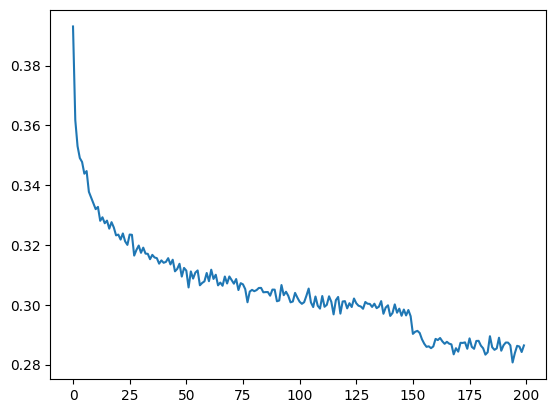

In [13]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [14]:
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 1.9120296239852905
val 2.0212268829345703
test 2.0196609497070312


In [21]:

for _ in range(20):
    
    out = []
    context = [0] * block_size 
    while True:
  
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)

      ix = torch.multinomial(probs, num_samples=1).item()

      context = context[1:] + [ix]
      out.append(ix)

      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) 

kelsandros.
yohinia.
adea.
arione.
tenani.
nein.
reyaank.
noella.
huaina.
nus.
elianna.
safira.
loun.
kennasher.
arielle.
alarius.
arkanno.
arkaana.
calynn.
elianna.


In [22]:
x_small = torch.tensor([
    [[1.0], [3.0]],
    [[5.0], [7.0]],
])

print("Girdi şekli:", x_small.shape)
print("Eski ortalama:", x_small.mean(0, keepdim=True))
print("Doğru ortalama:", x_small.mean((0, 1), keepdim=True))

Girdi şekli: torch.Size([2, 2, 1])
Eski ortalama: tensor([[[3.],
         [5.]]])
Doğru ortalama: tensor([[[4.]]])


In [23]:
ornek_sekil = torch.empty(batch_size, 4, n_hidden)
print('BatchNorm girdisi:', tuple(ornek_sekil.shape))
print('Eski ortalama şekli:', tuple(ornek_sekil.mean(0, keepdim=True).shape))
print('Doğru ortalama şekli:', tuple(ornek_sekil.mean((0, 1), keepdim=True).shape))

BatchNorm girdisi: (32, 4, 68)
Eski ortalama şekli: (1, 4, 68)
Doğru ortalama şekli: (1, 1, 68)


In [24]:
class EskiBatchNorm1d(BatchNorm1d):
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)  # Hatalı: 3B girdide konum ekseni kalıyor.
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

In [25]:
def gorev4_model_kur(bn_class):
    sonuc = Sequential([
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), bn_class(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), bn_class(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), bn_class(n_hidden), Tanh(),
        Linear(n_hidden, vocab_size),
    ])
    with torch.no_grad():
        sonuc.layers[-1].weight *= 0.1
    for p in sonuc.parameters():
        p.requires_grad = True
    return sonuc


def gorev4_egit(bn_class, ad):
    torch.manual_seed(42)
    sonuc = gorev4_model_kur(bn_class)
    params = sonuc.parameters()
    print(ad, 'parametre:', sum(p.nelement() for p in params))
    for i in range(max_steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        Xb, Yb = Xtr[ix], Ytr[ix]
        loss = F.cross_entropy(sonuc(Xb), Yb)
        for p in params:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < 150000 else 0.01
        for p in params:
            p.data += -lr * p.grad
        if i % 50000 == 0:
            print(f'{ad} {i:6d}/{max_steps}: {loss.item():.4f}')

    for layer in sonuc.layers:
        layer.training = False
    with torch.no_grad():
        dev_loss = F.cross_entropy(sonuc(Xdev), Ydev).item()
    print(f'{ad} dev loss: {dev_loss:.6f}')
    return sonuc, dev_loss

In [26]:
hatalı_model, dev_once = gorev4_egit(EskiBatchNorm1d, 'ÖNCE')

ÖNCE parametre: 22397
ÖNCE      0/200000: 3.3107
ÖNCE  50000/200000: 2.2678
ÖNCE 100000/200000: 1.6974
ÖNCE 150000/200000: 1.6929
ÖNCE dev loss: 2.028661


In [27]:
duzeltilmis_model, dev_sonra = gorev4_egit(BatchNorm1d, 'SONRA')

SONRA parametre: 22397
SONRA      0/200000: 3.3142
SONRA  50000/200000: 2.4183
SONRA 100000/200000: 1.5931
SONRA 150000/200000: 1.7118
SONRA dev loss: 2.020194


In [28]:
print(f'Önce (hatalı)       : {dev_once:.6f}')
print(f'Sonra (düzeltilmiş): {dev_sonra:.6f}')
print(f'Dev loss düşüşü    : {dev_once - dev_sonra:+.6f}')

Önce (hatalı)       : 2.028661
Sonra (düzeltilmiş): 2.020194
Dev loss düşüşü    : +0.008467
